# Analyze Latent Space Trajectories

This notebook loads the full latent space rollout data generated by `evaluate_latent_space.py`. It then uses the `plot_latent_trajectories` function from the `mhd_surrogate_core` package to visualize the evolution of the predicted latent state versus the ground truth.

This is a powerful diagnostic tool for understanding *how* the learned linear dynamics are failing or succeeding.

### 1. Setup and Imports

In [11]:
from pathlib import Path

# Make sure your packages are installed in editable mode
from mhd_surrogate_core.plot import plot_latent_trajectories

### 2. Specify Evaluation File Path and Plot

**Action Required:** Change the `eval_file_path` variable below to point to the specific `latent_rollout_error.npz` file you want to analyze. This file is generated by the `evaluate_latent_space.py` script.

2025-07-06 16:15:55,202 - INFO - Loading latent trajectories from /raid/skowronek/eval/param_sweep_04_07_25/lr_1e-4_ld_1024_wr_1.0_wp_1.0_wl_10.0_we_0.1/latent_rollout_error_train_val.npz...


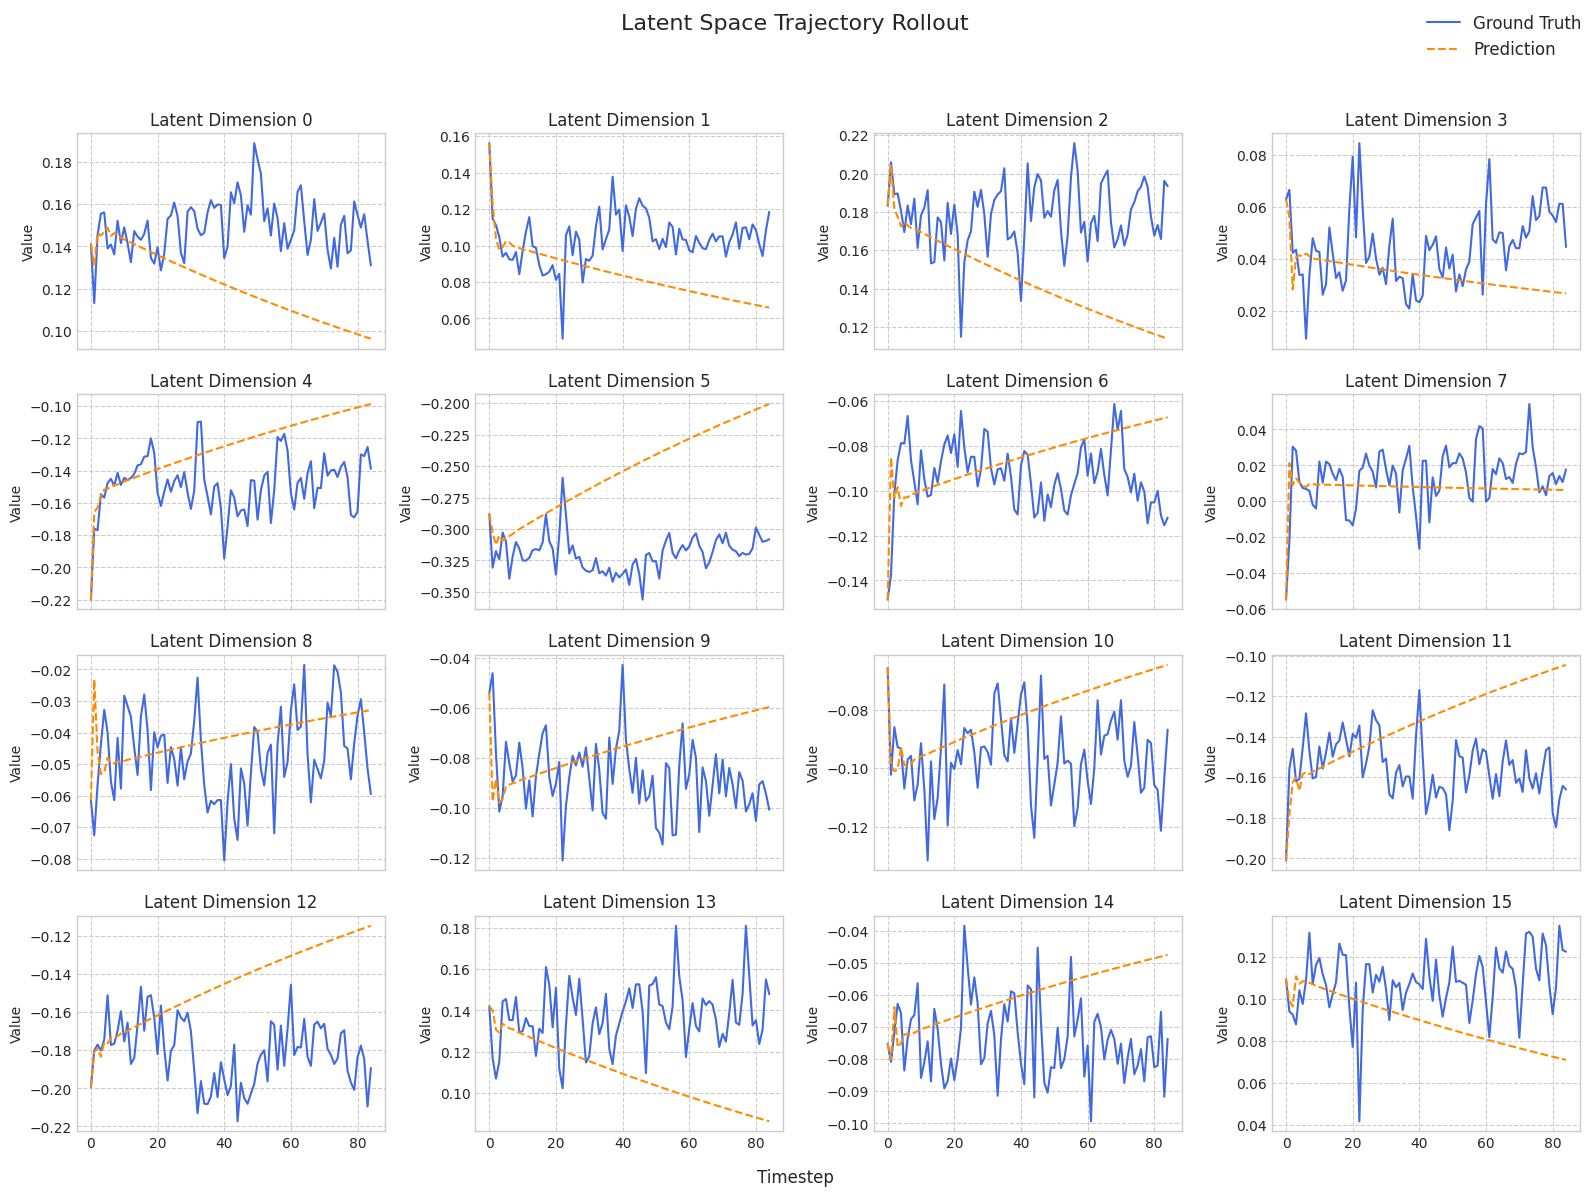

In [12]:
# Example path - update this to your specific run's output.
eval_file_path = Path("/raid/skowronek/eval/param_sweep_04_07_25/lr_1e-4_ld_1024_wr_1.0_wp_1.0_wl_10.0_we_0.1/latent_rollout_error_train_val.npz")

# Call the plotting function
if eval_file_path.exists():
    # You can change the number of dimensions to plot, e.g., num_dims_to_plot=8
    plot_latent_trajectories(eval_file_path, num_dims_to_plot=16)
else:
    print(f"ERROR: Evaluation file not found at {eval_file_path}")
    print("Please run evaluate_latent_space.py first and/or update the path.")

### Analysis

This plot allows for a direct visual comparison of the true dynamics (solid blue line) and the dynamics predicted by the linear Koopman operator (dashed orange line) in the latent space.

- **A Good Linear Model:** The predicted trajectory should closely follow the ground truth trajectory for most dimensions. The shapes and frequencies of any oscillations should match.
- **Common Failure Modes:**
  - **Decay to Zero:** If the predicted lines quickly go to zero, it means the eigenvalues of the learned Koopman operator all have magnitudes less than 1, causing the dynamics to be overly damped.
  - **Explosion:** If the predicted lines diverge to infinity, it means the operator has unstable eigenvalues with magnitudes greater than 1.
  - **Frequency Mismatch:** If the predicted lines oscillate but at a different frequency than the ground truth, it indicates the imaginary parts of the Koopman eigenvalues are incorrect.